# Predictive Modeling and Risk Scoring for Bank Customer Churn

## Objective
The objective of this project is to build a machine learning system capable of predicting customer churn and generating churn risk scores for proactive retention strategies in banking.

# Import Required Libraries

This section imports all necessary libraries for:
- data analysis
- visualization
- preprocessing
- machine learning
- evaluation

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

The dataset contains customer demographic, financial, and engagement-related attributes used to predict customer churn.

In [13]:
df = pd.read_csv("../data/bank_churn.csv")


In [14]:
df.head()


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
df.shape


(10000, 14)

# Dataset Overview

We inspect:
- number of rows and columns
- datatypes
- missing values
- feature structure

In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


# Exploratory Data Analysis (EDA)

EDA is performed to understand customer behavior patterns, feature distributions, and relationships influencing customer churn.

## Customer Churn Distribution

This visualization shows the proportion of customers who stayed versus customers who exited the bank.

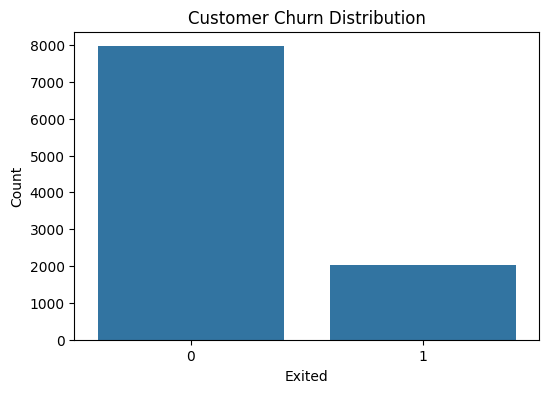

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Distribution")

plt.xlabel("Exited")

plt.ylabel("Count")

plt.show()

## Age Distribution by Churn Status

This analysis helps understand how customer age relates to churn behavior.

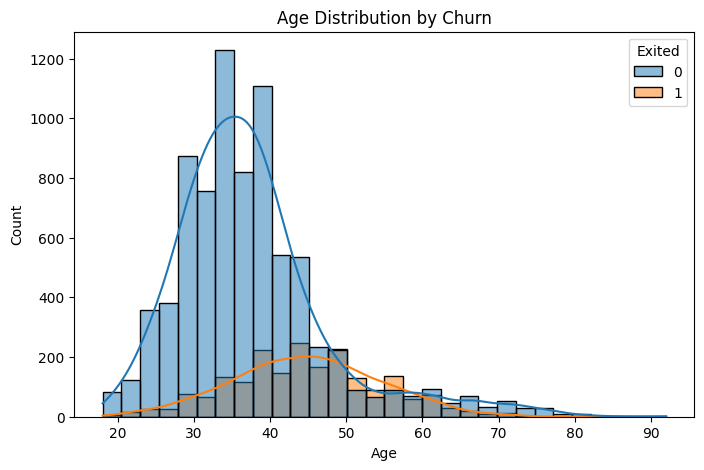

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    hue="Exited",
    kde=True,
    bins=30
)

plt.title("Age Distribution by Churn")

plt.show()

## Geography and Customer Churn

This visualization examines churn variation across different countries.

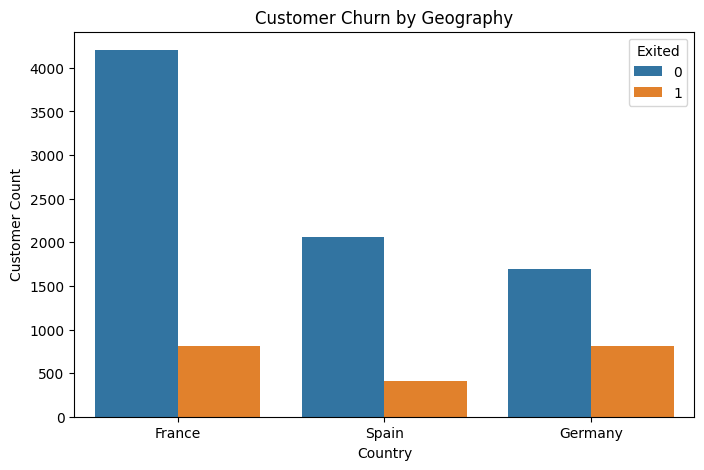

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Geography",
    hue="Exited",
    data=df_original
)

plt.title("Customer Churn by Geography")

plt.xlabel("Country")

plt.ylabel("Customer Count")

plt.show()

In [20]:
df_original = df.copy()

## Credit Score Distribution

This analysis evaluates whether customer creditworthiness influences churn behavior.

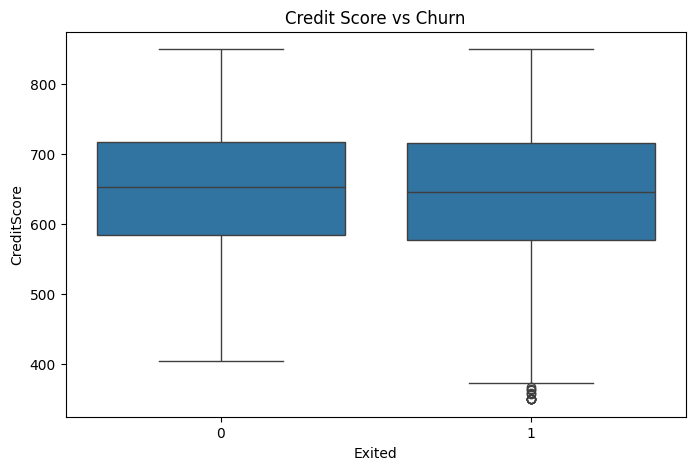

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Exited",
    y="CreditScore",
    data=df
)

plt.title("Credit Score vs Churn")

plt.show()

## Account Balance and Churn

This visualization analyzes how account balance impacts churn probability.

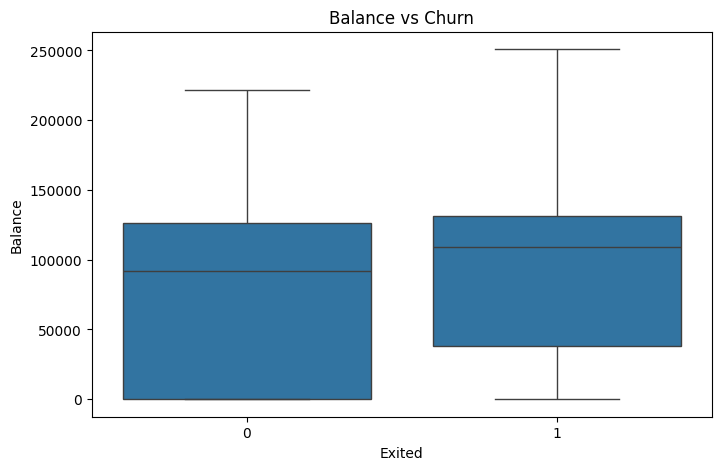

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Exited",
    y="Balance",
    data=df
)

plt.title("Balance vs Churn")

plt.show()

## Active Membership and Churn

This analysis evaluates the relationship between customer activity status and churn behavior.

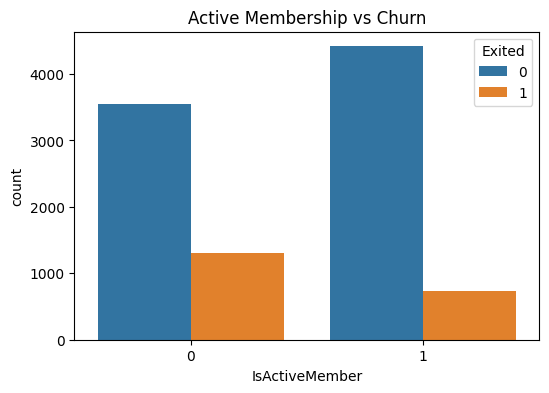

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="IsActiveMember",
    hue="Exited",
    data=df
)

plt.title("Active Membership vs Churn")

plt.show()

## Correlation Heatmap

The heatmap visualizes relationships among numerical variables and helps identify influential features associated with churn.

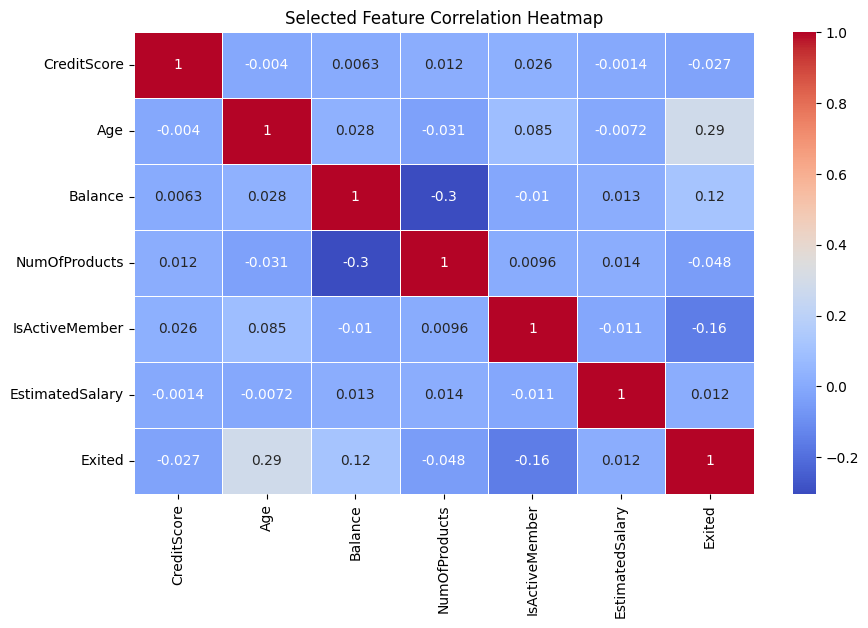

In [24]:
selected_columns = [
    "CreditScore",
    "Age",
    "Balance",
    "NumOfProducts",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited"
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[selected_columns].corr(),
    cmap="coolwarm",
    annot=True,
    linewidths=0.5
)

plt.title("Selected Feature Correlation Heatmap")

plt.show()

# Key EDA Insights

### Major Observations:
- Customer churn is imbalanced, with fewer churned customers.
- Older customers show higher churn tendencies.
- Customers with higher balances are more likely to churn.
- Inactive customers demonstrate increased churn probability.
- Product usage and engagement significantly influence retention behavior.

# Data Cleaning

CustomerId and Surname are removed because they do not contribute meaningful predictive information.

In [25]:
df.drop(["CustomerId", "Surname"], axis=1, inplace=True, errors="ignore")

In [26]:
df.isnull().sum()

Year               0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# Categorical Feature Encoding

Machine learning models require numerical input.  
Categorical variables are converted into numerical representations using one-hot encoding.

In [27]:
df_original = df.copy()
df = pd.get_dummies(df, drop_first=True)

In [28]:
df.head()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,2025,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2025,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,2025,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,2025,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,2025,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


# Feature Engineering

Additional derived features were created to improve model learning and capture hidden behavioral relationships.

### Created Features:
- BalanceSalaryRatio
- TenureAgeRatio
- ProductsPerBalance

In [29]:
df["BalanceSalaryRatio"] = df["Balance"] / (df["EstimatedSalary"] + 1)

df["TenureAgeRatio"] = df["Tenure"] / (df["Age"] + 1)

df["ProductsPerBalance"] = df["NumOfProducts"] / (df["Balance"] + 1)

In [30]:
df.drop("Year", axis=1, inplace=True)
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model

Logistic Regression is used as a baseline interpretable classification model.

In [33]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8105
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1593
           1       0.60      0.21      0.31       407

    accuracy                           0.81      2000
   macro avg       0.71      0.59      0.60      2000
weighted avg       0.78      0.81      0.77      2000



# Random Forest Classifier

Random Forest is an ensemble learning model capable of capturing non-linear relationships and improving predictive performance.

In [35]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.869
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.83      0.44      0.58       407

    accuracy                           0.87      2000
   macro avg       0.85      0.71      0.75      2000
weighted avg       0.87      0.87      0.85      2000



# Model Evaluation

The Random Forest model achieved better predictive performance compared to Logistic Regression.

### Key Observations:
- Improved churn prediction capability
- Better precision and recall balance
- Stronger classification performance

# Advanced Model Evaluation

Advanced evaluation metrics are used to assess the classification performance and reliability of the churn prediction model.

## Confusion Matrix

The confusion matrix helps visualize:
- correct predictions,
- false positives,
- false negatives,
- and overall classification behavior.

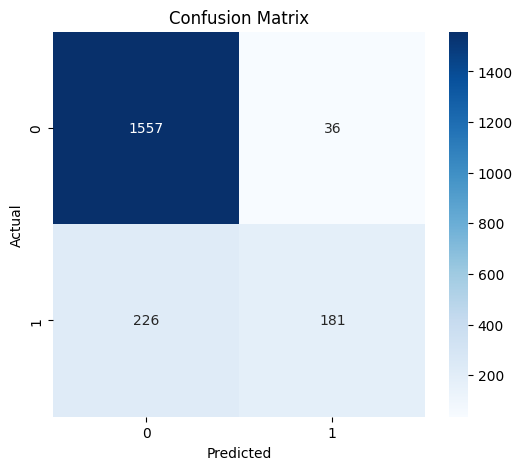

In [37]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## ROC-AUC Score

ROC-AUC evaluates the model’s ability to distinguish between churned and retained customers across different classification thresholds.

In [53]:
roc_score = roc_auc_score(y_test, risk_scores)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.863954863954864


In [39]:
from sklearn.metrics import roc_curve

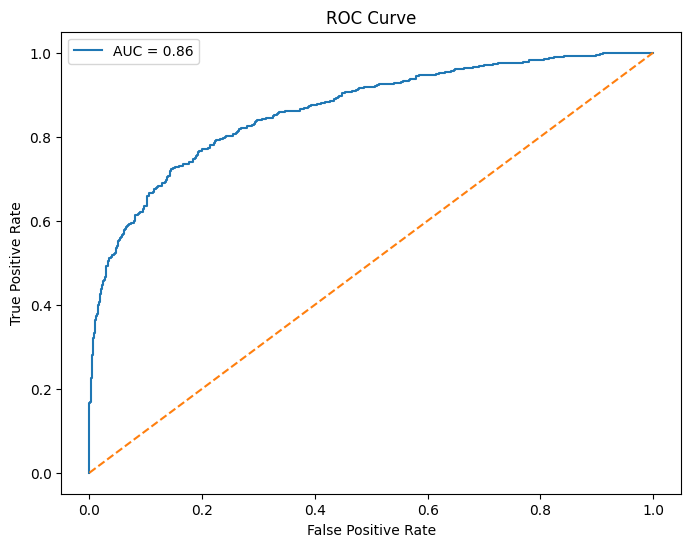

In [54]:
fpr, tpr, thresholds = roc_curve(y_test, risk_scores)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_score:.2f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Advanced Evaluation Insights

### Key Findings:
- The confusion matrix indicates strong prediction capability for retained customers.
- The ROC-AUC score demonstrates the model’s ability to distinguish churn patterns effectively.
- The Random Forest model provides balanced predictive performance suitable for churn risk analysis and retention strategy development.

# Feature Importance Analysis

Feature importance analysis helps identify the major drivers influencing customer churn behavior.

In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)


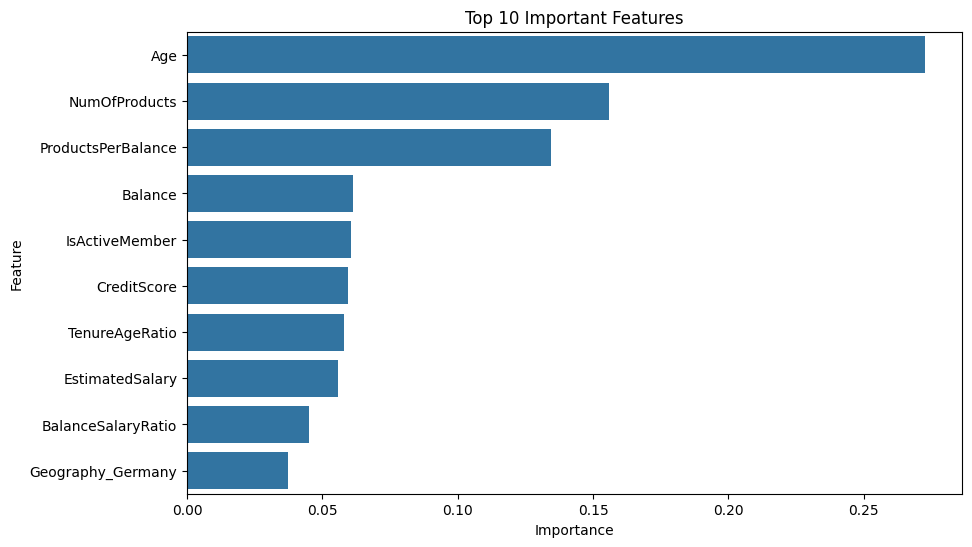

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

### Insights
- Age is the strongest predictor of churn.
- Product usage strongly impacts retention.
- Customer engagement and financial behavior significantly influence churn probability.

# Model Explainability using SHAP

SHAP (SHapley Additive exPlanations) is used to interpret machine learning predictions and identify how individual features contribute to customer churn risk.

In [43]:
import shap
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

## SHAP Summary Plot

The SHAP summary plot highlights the most influential features contributing to churn prediction across all customers.

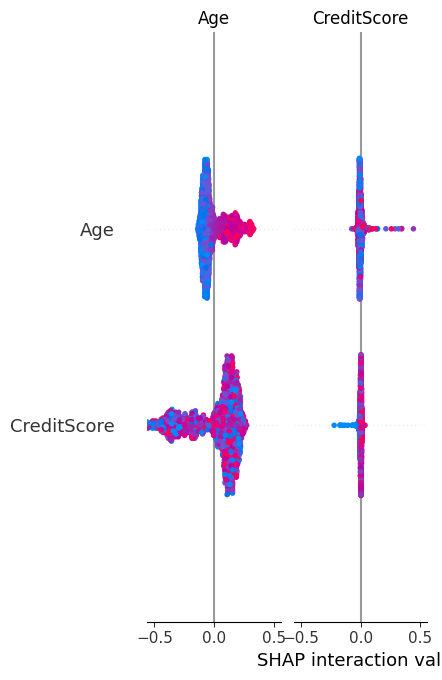

In [44]:
shap.summary_plot(
    shap_values,
    X_test
)

## SHAP Feature Importance

This visualization ranks features based on their overall impact on model predictions.

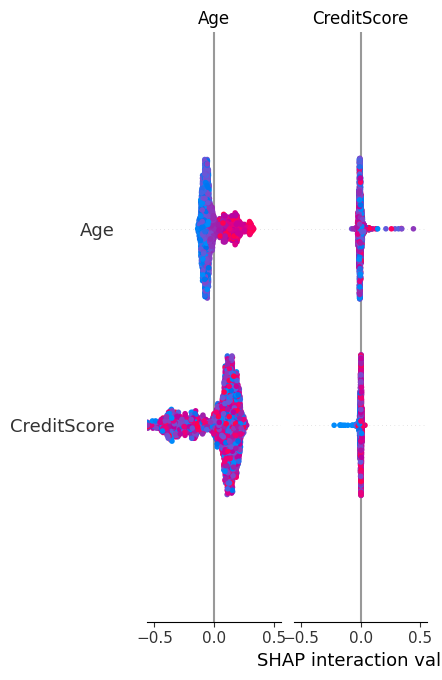

In [45]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# SHAP Explainability Insights

### Key Interpretations:
- Age is one of the strongest contributors to churn prediction.
- Product utilization significantly impacts customer retention behavior.
- Balance patterns and customer engagement influence churn probability.
- SHAP improves model transparency and supports explainable AI decision-making.

# Churn Risk Scoring System

The model generates churn probability scores between 0 and 1 for each customer.

Risk categories:
- Low Risk (<30%)
- Medium Risk (30–60%)
- High Risk (>60%)

In [46]:
risk_scores = rf.predict_proba(X_test)[:,1]

In [47]:
results = pd.DataFrame({
    "Actual": y_test,
    "RiskScore": risk_scores
})

results.head()

,Actual,RiskScore
5702,0,0.009813
3667,0,0.077558
1617,0,0.045125
5673,0,0.073316
4272,0,0.103280


In [48]:
def risk_category(score):
    
    if score < 0.3:
        return "Low Risk"
    
    elif score < 0.6:
        return "Medium Risk"
    
    else:
        return "High Risk"

In [49]:
results["RiskCategory"] = results["RiskScore"].apply(risk_category)

results.head()

,Actual,RiskScore,RiskCategory
5702,0,0.009813,Low Risk
3667,0,0.077558,Low Risk
1617,0,0.045125,Low Risk
5673,0,0.073316,Low Risk
4272,0,0.103280,Low Risk


In [50]:
import joblib

joblib.dump(rf, "../models/churn_model.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

# Conclusion

This project successfully developed a machine learning–based customer churn prediction and risk scoring system for banking customers.

Multiple machine learning models were trained and evaluated, including Logistic Regression and Random Forest Classifier. Among them, the Random Forest model achieved superior predictive performance and demonstrated better capability in identifying potential customer churn.

Feature engineering and feature importance analysis provided valuable business insights into the major factors influencing churn behavior, such as age, product usage, balance patterns, and customer engagement.

The generated churn risk scores can help banks:
- identify high-risk customers early,
- improve customer retention strategies,
- optimize marketing efforts,
- and support data-driven business decisions.

This project demonstrates how predictive analytics and machine learning can transform traditional churn analysis into proactive customer retention intelligence.